# PSNR-like metric over top-importance neurons

Метрика: берём top 1% нейронов по `|SegmentIG|` на `model.22` и считаем `sum(log10(255^2 / delta^2))`. Для `delta=0` используется явный `eps`, чтобы не получать бесконечности.

## Setup

Работаем на текущем `COCO_people` кэше и переиспользуем `layer_maps` (`delta_chw`, `segmentig_chw`).

In [1]:
from pathlib import Path
import sys

_nb_cwd = Path.cwd()
if (_nb_cwd / "new_experiments" / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd / "new_experiments"))
elif (_nb_cwd / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd))
else:
    raise RuntimeError(f"Unexpected cwd={_nb_cwd}; run from repo root or new_experiments")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from patch_success_analysis.notebook_setup import (
    ensure_new_experiments_cwd,
    load_segmentig_success_failure_rows,
    make_coco_people_patch_success_experiment,
)
from patch_success_analysis import metric_leaderboard, psnr_metrics

cwd = ensure_new_experiments_cwd()
attack_config, config, exp = make_coco_people_patch_success_experiment()
cache = exp.build_or_load_cache(force=False)

print(f"cwd={cwd}")
print(f"attack cache key={attack_config.cache_key()}")
print(f"attack cache path={attack_config.cache_path}")
print(f"examples={len(cache.examples)}")

cwd=/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments
attack cache key=e91cdfc4a2c4e20d
attack cache path=new_experiments/outputs/patch_success_analysis/cache/attack_pool_e91cdfc4a2c4e20d.pkl
examples=5650


## Baseline SegmentIG metrics

Нужны для сравнения с лучшими предыдущими scalar-метриками. `force=False` должен брать существующий `segmentig_success_failure_metrics` кэш; если его нет, код будет досчитывать missing `layer_maps` стандартным механизмом.

In [2]:
force_segmentig_recompute = False

sf, rows_df, quality_df = load_segmentig_success_failure_rows(
    exp,
    force=force_segmentig_recompute,
)
quality_df = quality_df.copy()
quality_df["family"] = "segmentig"

print(f"rows={len(rows_df)}, metrics={len(quality_df)}, loaded_from_cache={sf.get('loaded_from_cache')}")
print(sf.get("cache_path"))
display(quality_df.head(15))

rows=5646, metrics=207, loaded_from_cache=True
new_experiments/outputs/patch_success_analysis/cache/segmentig_success_failure_metrics_3362be6645634ce2.pkl


,metric,roc_auc,best_accuracy,best_threshold,best_direction,figure_path,family
61,segmentig_hand_rank_ratio_top5_top25,0.669002,0.640985,0.228035,1,new_experiments/outputs/patch_success_analysis...,segmentig
7,segmentig_delta_energy_in_importance_top,0.667132,0.639568,0.056406,1,new_experiments/outputs/patch_success_analysis...,segmentig
72,segmentig_hand_overlap_top5_delta_in_topA,0.667132,0.639568,0.056406,1,new_experiments/outputs/patch_success_analysis...,segmentig
55,segmentig_hand_rank_top5_delta_frac,0.667376,0.639391,0.056406,1,new_experiments/outputs/patch_success_analysis...,segmentig
5,segmentig_align_top_jaccard,0.667112,0.637797,0.039356,1,new_experiments/outputs/patch_success_analysis...,segmentig
71,segmentig_hand_overlap_top5_jaccard,0.667112,0.637797,0.039356,1,new_experiments/outputs/patch_success_analysis...,segmentig
56,segmentig_hand_rank_top6_delta_frac,0.666895,0.637442,0.064968,1,new_experiments/outputs/patch_success_analysis...,segmentig
19,segmentig_delta_energy_importance_bins_top10_l...,0.666285,0.637088,0.058602,1,new_experiments/outputs/patch_success_analysis...,segmentig
74,segmentig_hand_overlap_top10_jaccard,0.659817,0.636026,0.054759,1,new_experiments/outputs/patch_success_analysis...,segmentig
21,segmentig_delta_energy_importance_bins_top10_exp,0.664821,0.635671,0.038404,1,new_experiments/outputs/patch_success_analysis...,segmentig


## PSNR-like top 1% importance metric

Считаем новую метрику по сохранённым картам слоя. Основная колонка для проверки гипотезы: `psnr_top1_importance_sum`.

In [3]:
force_psnr_recompute = False

psnr_result = psnr_metrics.compute_or_load_psnr_importance_top_metrics(
    exp,
    examples=cache.examples,
    layer_name=config.target_layer,
    top_percent=1.0,
    max_value=255.0,
    eps=1e-12,
    force=force_psnr_recompute,
)

psnr_rows_df = pd.DataFrame(psnr_result["rows"])
psnr_quality_df = psnr_result["quality"].copy()
psnr_regression_df = psnr_result["regression"].copy()
psnr_metric = "psnr_top1_importance_sum"

print(f"loaded_from_cache={psnr_result['loaded_from_cache']}")
print(f"cache_path={psnr_result['cache_path']}")
print(f"rows={len(psnr_rows_df)}, skipped={len(psnr_result['skipped'])}")
if psnr_result["skipped"]:
    display(pd.DataFrame(psnr_result["skipped"]).head(20))

display(psnr_rows_df[["success", "drop", psnr_metric, "psnr_top1_importance_mean", "psnr_top1_importance_zero_frac", "psnr_top1_importance_k"]].describe())
display(psnr_quality_df)
display(psnr_regression_df)

loaded_from_cache=False
cache_path=new_experiments/outputs/patch_success_analysis/cache/psnr_importance_top_metrics_c16afd6061b24e47.pkl
rows=5646, skipped=4


,path,success,drop,reason
0,../datasets/COCO_people/03520_train2017_image1...,False,-0.147283,missing layer_maps cache
1,../datasets/COCO_people/03370_train2017_image5...,False,-0.751137,missing layer_maps cache
2,../datasets/COCO_people/01029_train2017_image3...,False,-0.195723,missing layer_maps cache
3,../datasets/COCO_people/04404_train2017_image7...,False,0.000000,missing layer_maps cache


,drop,psnr_top1_importance_sum,psnr_top1_importance_mean,psnr_top1_importance_zero_frac,psnr_top1_importance_k
count,5646.000000,5646.000000,5646.000000,5646.000000,5646.0
mean,0.432727,13497.532935,6.590592,0.000021,2048.0
std,0.339241,580.833444,0.283610,0.000103,0.0
min,-0.859980,12127.272332,5.921520,0.000000,2048.0
25%,0.128852,13084.775775,6.389051,0.000000,2048.0
50%,0.350645,13398.030961,6.542007,0.000000,2048.0
75%,0.804987,13804.018475,6.740243,0.000000,2048.0
max,0.948292,17243.969081,8.419907,0.000977,2048.0


,metric,roc_auc,best_accuracy,best_threshold,best_direction,raw_roc_auc,family
0,psnr_top1_importance_sum,0.685085,0.654623,13603.532436,-1,0.314915,psnr_top_importance
1,psnr_top1_importance_mean,0.685085,0.654623,6.642350,-1,0.314915,psnr_top_importance
2,psnr_top1_importance_min,0.573951,0.578994,3.425723,-1,0.426049,psnr_top_importance
3,psnr_top1_importance_max,0.539058,0.536132,15.643427,-1,0.460942,psnr_top_importance
4,psnr_top1_importance_zero_frac,0.504928,0.533652,0.000244,-1,0.495072,psnr_top_importance


,metric,n,coverage,pearson,spearman,kendall,abs_pearson,abs_spearman,abs_kendall,mutual_info,...,linear_slope,linear_intercept,linear_r2,calibrated_mae,calibrated_rmse,calibrated_nrmse,mutual_info_norm,calibrated_error_score,main_score,family
0,psnr_top1_importance_sum,5646,1.0,-0.287503,-0.281387,-0.199388,0.287503,0.281387,0.199388,0.150782,...,-0.000168,2.699214,0.082658,0.281297,0.324890,0.957780,1.000000,0.510783,0.375178,psnr_top_importance
1,psnr_top1_importance_mean,5646,1.0,-0.287503,-0.281387,-0.199388,0.287503,0.281387,0.199388,0.150781,...,-0.343897,2.699214,0.082658,0.281297,0.324890,0.957780,0.999995,0.510783,0.375178,psnr_top_importance
2,psnr_top1_importance_min,5646,1.0,-0.133494,-0.136569,-0.092022,0.133494,0.136569,0.092022,0.049493,...,-0.130206,0.843450,0.017821,0.301474,0.336175,0.991050,0.328240,0.502248,0.189071,psnr_top_importance
3,psnr_top1_importance_max,5646,1.0,-0.062132,-0.074439,-0.049845,0.062132,0.074439,0.049845,0.004117,...,-0.019055,0.706663,0.003860,0.304987,0.338556,0.998068,0.027302,0.500483,0.112497,psnr_top_importance
4,psnr_top1_importance_zero_frac,5646,1.0,-0.013247,-0.024773,-0.020237,0.013247,0.024773,0.020237,0.002167,...,-43.543223,0.433658,0.000175,0.305716,0.339181,0.999912,0.014370,0.500022,0.088831,psnr_top_importance


## Visual check: distribution, drop scatter, ROC

На ROC используется направление threshold, найденное через максимизацию accuracy.

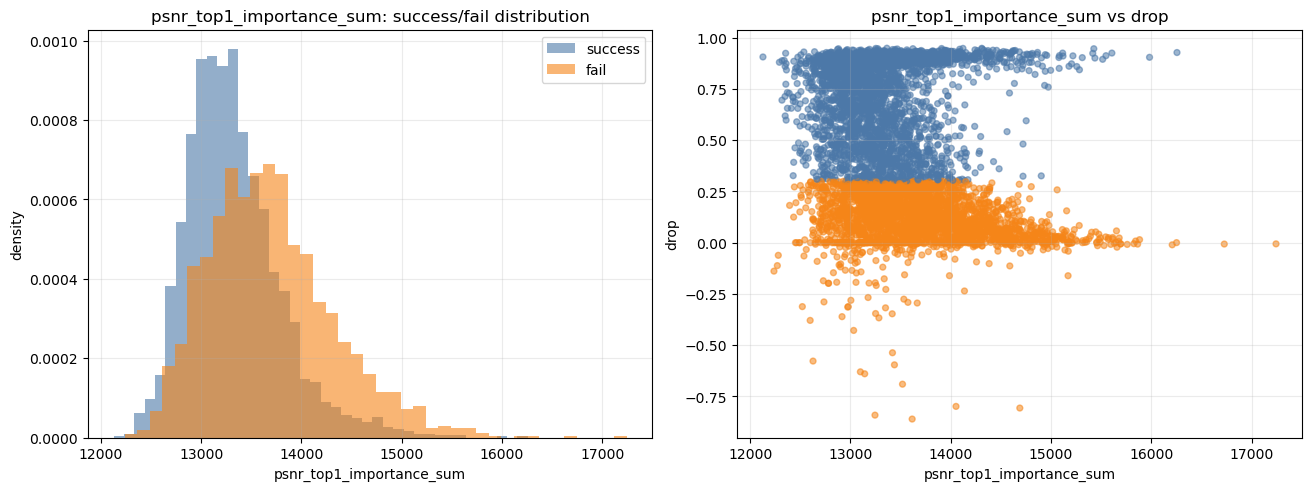

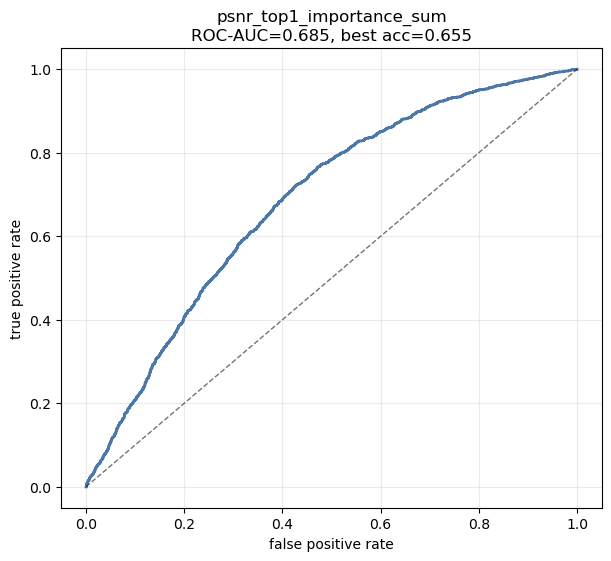

In [4]:
fig = psnr_metrics.plot_metric_distribution(psnr_rows_df, metric=psnr_metric)
plt.show()

fig = psnr_metrics.plot_metric_roc(psnr_rows_df, psnr_quality_df, metric=psnr_metric)
plt.show()

## Percent sweep: top 0..10%

Перебираем top-percent по важности от 0% до 10% с шагом 0.1%. Основная кривая — `sum(log10(255^2 / delta^2))`; пунктиром дополнительно показан `mean`, чтобы видеть эффект нормировки на число выбранных нейронов.

/Users/ashentide/anaconda3/envs/IAD/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/ashentide/anaconda3/envs/IAD/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/ashentide/anaconda3/envs/IAD/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


loaded_from_cache=False
cache_path=new_experiments/outputs/patch_success_analysis/cache/psnr_importance_percent_sweep_fad0894b7c4ba3e7.pkl
rows=5646, skipped=4


,path,success,drop,reason
0,../datasets/COCO_people/03520_train2017_image1...,False,-0.147283,missing layer_maps cache
1,../datasets/COCO_people/03370_train2017_image5...,False,-0.751137,missing layer_maps cache
2,../datasets/COCO_people/01029_train2017_image3...,False,-0.195723,missing layer_maps cache
3,../datasets/COCO_people/04404_train2017_image7...,False,0.000000,missing layer_maps cache


,metric,roc_auc,best_accuracy,best_threshold,best_direction,raw_roc_auc,family,top_percent,aggregate
0,psnr_top6p1_importance_sum,0.694806,0.665250,86713.675442,-1,0.305194,psnr_percent_sweep,6.1,sum
1,psnr_top6p1_importance_mean,0.694806,0.665250,6.940981,-1,0.305194,psnr_percent_sweep,6.1,mean
2,psnr_top6p2_importance_sum,0.694364,0.665250,88120.620515,-1,0.305636,psnr_percent_sweep,6.2,sum
3,psnr_top6p2_importance_mean,0.694364,0.665250,6.939724,-1,0.305636,psnr_percent_sweep,6.2,mean
4,psnr_top5p9_importance_sum,0.695420,0.665073,83721.513806,-1,0.304580,psnr_percent_sweep,5.9,sum
5,psnr_top5p9_importance_mean,0.695420,0.665073,6.928868,-1,0.304580,psnr_percent_sweep,5.9,mean
6,psnr_top5p8_importance_sum,0.695443,0.664896,82261.041275,-1,0.304557,psnr_percent_sweep,5.8,sum
7,psnr_top5p8_importance_mean,0.695443,0.664896,6.925496,-1,0.304557,psnr_percent_sweep,5.8,mean
8,psnr_top6_importance_sum,0.695223,0.664896,85173.895089,-1,0.304777,psnr_percent_sweep,6.0,sum
9,psnr_top6_importance_mean,0.695223,0.664896,6.931469,-1,0.304777,psnr_percent_sweep,6.0,mean


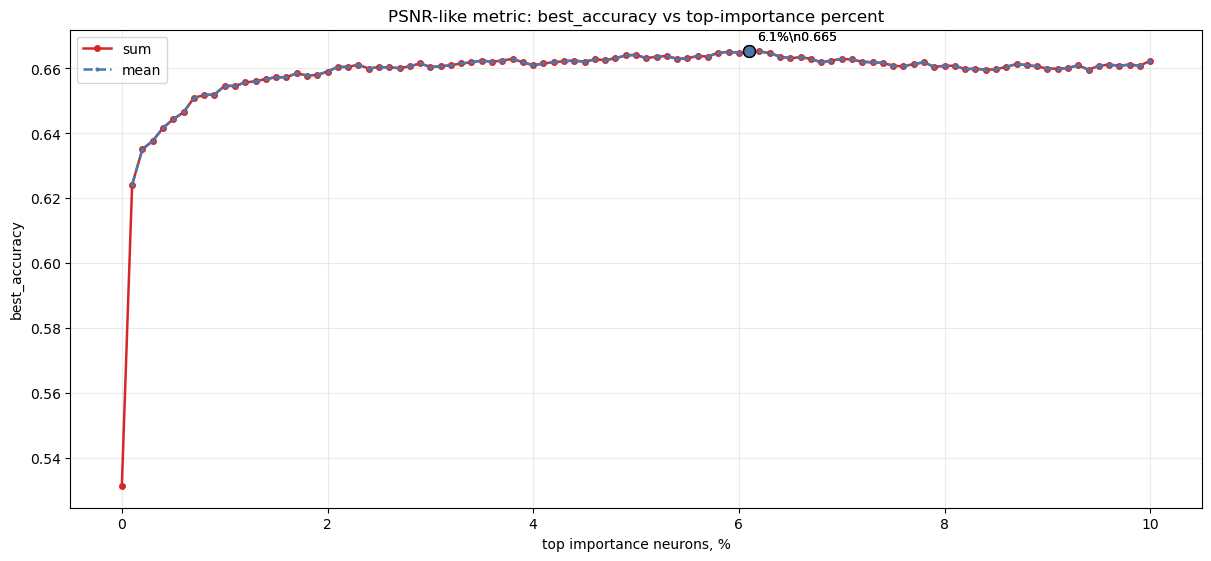

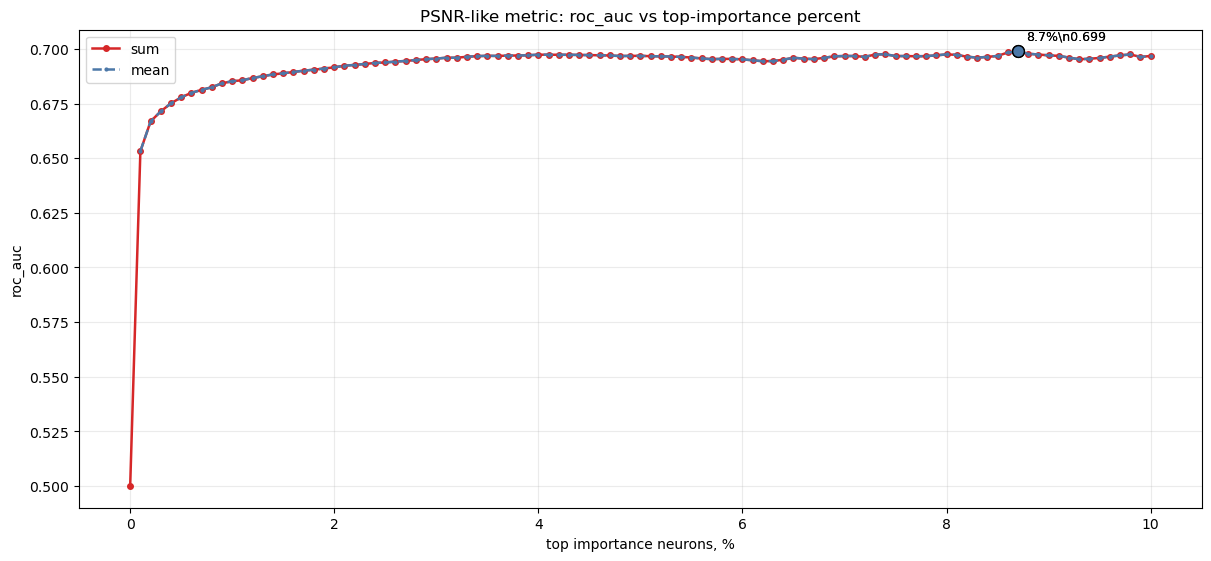

In [7]:
force_psnr_percent_sweep_recompute = False

psnr_percentages = [round(v * 0.1, 1) for v in range(0, 101)]
psnr_sweep_result = psnr_metrics.compute_or_load_psnr_importance_percent_sweep(
    exp,
    examples=cache.examples,
    layer_name=config.target_layer,
    percentages=psnr_percentages,
    max_value=255.0,
    eps=1e-12,
    force=force_psnr_percent_sweep_recompute,
)

psnr_sweep_rows_df = pd.DataFrame(psnr_sweep_result["rows"])
psnr_sweep_quality_df = psnr_sweep_result["quality"].copy()
psnr_sweep_regression_df = psnr_sweep_result["regression"].copy()

print(f"loaded_from_cache={psnr_sweep_result['loaded_from_cache']}")
print(f"cache_path={psnr_sweep_result['cache_path']}")
print(f"rows={len(psnr_sweep_rows_df)}, skipped={len(psnr_sweep_result['skipped'])}")
if psnr_sweep_result["skipped"]:
    display(pd.DataFrame(psnr_sweep_result["skipped"]).head(20))

psnr_sweep_sum_quality_df = (
    psnr_sweep_quality_df[psnr_sweep_quality_df["aggregate"] == "sum"]
    .sort_values("top_percent")
    .reset_index(drop=True)
)
display(psnr_sweep_quality_df.sort_values(["best_accuracy", "roc_auc"], ascending=False).head(20))

fig = psnr_metrics.plot_percent_sweep_accuracy(
    psnr_sweep_quality_df,
    score_col="best_accuracy",
)
plt.show()

fig = psnr_metrics.plot_percent_sweep_accuracy(
    psnr_sweep_quality_df,
    score_col="roc_auc",
)
plt.show()


## Accuracy / ROC-AUC comparison with global leaderboard

Собираем единую таблицу уже посчитанных метрик из кэшей всех текущих ноутбуков: SegmentIG/BinMetrics, SpreadVsPrecision, CovarianceExperiments, attribution-method suite, PSNR и patch-excluded spread. Тяжёлые карты/атрибуции не пересчитываются.


In [ ]:
force_metric_leaderboard_rebuild = False

leaderboard_result = metric_leaderboard.compute_or_load_metric_leaderboard(
    exp,
    force=force_metric_leaderboard_rebuild,
)
classification_leaderboard = leaderboard_result["classification"].copy()
regression_leaderboard = leaderboard_result["regression"].copy()

print(f"leaderboard loaded_from_cache={leaderboard_result['loaded_from_cache']}")
print(f"leaderboard cache_path={leaderboard_result['cache_path']}")
print(
    f"classification metrics={len(classification_leaderboard)}, "
    f"regression metrics={len(regression_leaderboard)}, "
    f"source caches={len(leaderboard_result['cache_files'])}"
)
if len(leaderboard_result["skipped"]):
    display(leaderboard_result["skipped"].head(20))

display(classification_leaderboard.head(30))
print("Best classification metric by source family")
display(metric_leaderboard.best_by_source_family(classification_leaderboard, score_col="best_accuracy"))

fig = metric_leaderboard.plot_leaderboard_bars(
    classification_leaderboard,
    score_col="best_accuracy",
    title="Global metric leaderboard: best accuracy",
    top_n=30,
)
plt.show()

fig = metric_leaderboard.plot_leaderboard_bars(
    classification_leaderboard,
    score_col="roc_auc",
    title="Global metric leaderboard: ROC-AUC",
    top_n=30,
)
plt.show()


## Drop correlation / regression comparison with global leaderboard

Используем ту же агрегированную таблицу для regression/correlation метрик: Pearson, Spearman, Kendall, distance correlation, MI, linear fit score и общий `main_score`.


In [ ]:
display(regression_leaderboard.head(30))
print("Best regression metric by source family")
display(metric_leaderboard.best_by_source_family(regression_leaderboard, score_col="main_score"))

fig = metric_leaderboard.plot_leaderboard_bars(
    regression_leaderboard,
    score_col="main_score",
    title="Global metric leaderboard: regression main score",
    top_n=30,
)
plt.show()

fig = metric_leaderboard.plot_leaderboard_bars(
    regression_leaderboard,
    score_col="abs_spearman",
    title="Global metric leaderboard: |Spearman| with drop",
    top_n=30,
)
plt.show()

fig = metric_leaderboard.plot_leaderboard_bars(
    regression_leaderboard,
    score_col="abs_pearson",
    title="Global metric leaderboard: |Pearson| with drop",
    top_n=30,
)
plt.show()
